- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

# M1.Ex2: Model Experience vs Salary

In [1]:
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import numpy as np

### Step 1. Load the data

In [2]:
url = "https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv"
df = pd.read_csv(url)
display(df.head())

,Experience Years,Salary
0,1.1,39343
1,1.2,42774
2,1.3,46205
3,1.5,37731
4,2.0,43525


### Step 2.a Assign variables `X` to the features and `y` to the target

In [3]:
# X must be 2D (DataFrame), y is 1D (Series)
X = df[['Experience Years']]  # feature matrix
y = df['Salary']              # target vector

print('X (first 5 rows):')
display(X.head())
print('y (first 5 values):')
print(y.head())

X (first 5 rows):


,Experience Years
0,1.1
1,1.2
2,1.3
3,1.5
4,2.0


y (first 5 values):
0    39343
1    42774
2    46205
3    37731
4    43525
Name: Salary, dtype: int64


### Step 2.b print the type of each

In [4]:
print('Type of X:', type(X))
print('Type of y:', type(y))

Type of X: <class 'pandas.DataFrame'>
Type of y: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [5]:
print('Target dtype:', y.dtype)
print()
print('The target (Salary) is NUMERICAL — it contains continuous integer values.')
print('Therefore, the task is REGRESSION (predicting a continuous number, not a category).')

Target dtype: int64

The target (Salary) is NUMERICAL — it contains continuous integer values.
Therefore, the task is REGRESSION (predicting a continuous number, not a category).


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [6]:
print('--- Feature Matrix X ---')
print(f'Shape            : {X.shape}')
print(f'Number of samples: {X.shape[0]}')
print(f'Number of columns: {X.shape[1]}')
print()
print('--- Target Vector y ---')
print(f'Shape            : {y.shape}')
print(f'Number of samples: {y.shape[0]}')

--- Feature Matrix X ---
Shape            : (40, 1)
Number of samples: 40
Number of columns: 1

--- Target Vector y ---
Shape            : (40,)
Number of samples: 40


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [7]:
summary = df.agg(['min', 'max', 'median', 'mean', 'std'])
print('Distribution Summary:')
display(summary)

Distribution Summary:


,Experience Years,Salary
min,1.100000,37731.000000
max,10.500000,122391.000000
median,4.600000,64472.500000
mean,5.152500,74743.625000
std,2.663715,25947.122885


### Step 5. Plot the feature vs the target

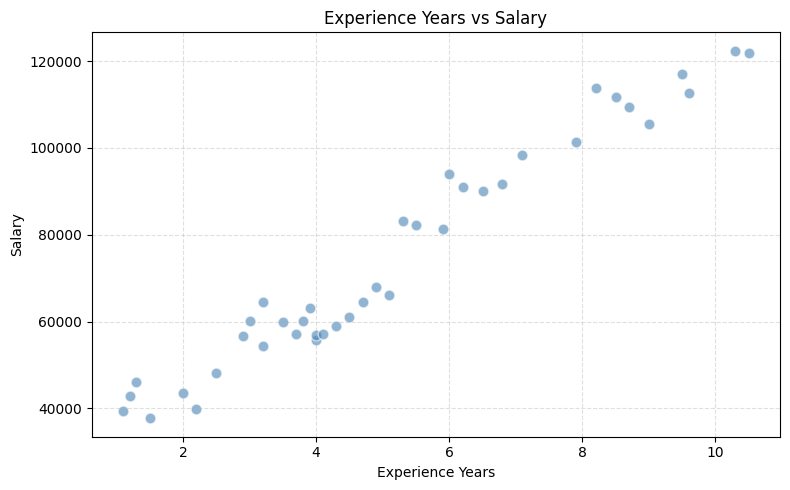

In [8]:
plt.figure(figsize=(8, 5))
plt.scatter(X, y, color='steelblue', alpha=0.6, edgecolors='white', s=60)
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Experience Years vs Salary')
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [9]:
correlation = df['Experience Years'].corr(df['Salary'])
print(f'Pearson Correlation Coefficient: {correlation:.4f}')
print()
print('The relationship is INCREASING (strong positive correlation).')
print('As Experience Years increases, Salary also tends to increase.')

Pearson Correlation Coefficient: 0.9777

The relationship is INCREASING (strong positive correlation).
As Experience Years increases, Salary also tends to increase.


### Step 7. Initialize a regression model

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
print('Model initialized:', model)

Model initialized: LinearRegression()


### Step 8. Split the dataset into train and test sets

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Total samples     : {len(df)}')
print(f'Training set size : {X_train.shape[0]} samples (80%)')
print(f'Test set size     : {X_test.shape[0]} samples (20%)')

Total samples     : 40
Training set size : 32 samples (80%)
Test set size     : 8 samples (20%)


### Step 9.a Train the model on the training set

In [12]:
model.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [13]:
slope     = model.coef_[0]    # salary increase per 1 year of experience
intercept = model.intercept_  # estimated salary at 0 years of experience

print(f'Slope     (coef_)     : {slope:.4f}')
print(f'Intercept (intercept_): {intercept:.4f}')
print()
print(f'Equation: Salary = {slope:.2f} * Experience_Years + {intercept:.2f}')

Slope     (coef_)     : 9408.0313
Intercept (intercept_): 26716.2502

Equation: Salary = 9408.03 * Experience_Years + 26716.25


### Step 9.c how much salary does a person get with 2 years of experience?

In [14]:
# Use the model to predict salary at 2 years of experience
years = 2
predicted_salary = model.predict([[years]])[0]

print(f'Predicted salary for {years} years of experience: ${predicted_salary:,.2f}')
print()
# Verify manually
manual = slope * years + intercept
print(f'Manual check (slope*2 + intercept): ${manual:,.2f}')

Predicted salary for 2 years of experience: $45,532.31

Manual check (slope*2 + intercept): $45,532.31


c:\Users\Abula\Desktop\B5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [15]:
# 6 months = 0.5 years
six_months_in_years = 6 / 12
salary_increase = slope * six_months_in_years

print(f'6 months in years               : {six_months_in_years} yrs')
print(f'Salary increase per 6 months    : ${salary_increase:,.2f}')

6 months in years               : 0.5 yrs
Salary increase per 6 months    : $4,704.02


### Step 9.e if one has zero experience, then how much is the estimated salary?

In [16]:
# When Experience Years = 0: Salary = slope*0 + intercept = intercept
print(f'Estimated salary with 0 years of experience (y-intercept): ${intercept:,.2f}')

Estimated salary with 0 years of experience (y-intercept): $26,716.25


### Step 10. Evaluate the model on the test set

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, y_pred)

print('Model Evaluation on Test Set:')
print(f'  MAE  (Mean Absolute Error) : ${mae:,.2f}')
print(f'  MSE  (Mean Squared Error)  : ${mse:,.2f}')
print(f'  RMSE (Root Mean Sq. Error) : ${rmse:,.2f}')
print(f'  R2   (R-squared Score)     : {r2:.4f}')
print()
print(f'The model explains {r2*100:.1f}% of the variance in Salary.')

Model Evaluation on Test Set:
  MAE  (Mean Absolute Error) : $6,419.91
  MSE  (Mean Squared Error)  : $48,077,731.17
  RMSE (Root Mean Sq. Error) : $6,933.81
  R2   (R-squared Score)     : 0.9069

The model explains 90.7% of the variance in Salary.


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [18]:
# Sample 3 rows from the test set
sample_X      = X_test.sample(3, random_state=1)
sample_y_true = y_test.loc[sample_X.index]
sample_y_pred = model.predict(sample_X)

comparison = pd.DataFrame({
    'Experience Years'        : sample_X['Experience Years'].values,
    'True Salary'             : sample_y_true.values,
    'Predicted Salary'        : sample_y_pred.round(2),
    'Residual (true - pred)'  : (sample_y_true.values - sample_y_pred).round(2)
})

display(comparison)
print()
print('Predictions are close to but not exactly equal to the true salaries.')
print('The residual shows the prediction error for each sample.')

,Experience Years,True Salary,Predicted Salary,Residual (true - pred)
0,6.2,91000,85046.04,5953.96
1,4.0,55794,64348.38,-8554.38
2,4.0,56957,64348.38,-7391.38



Predictions are close to but not exactly equal to the true salaries.
The residual shows the prediction error for each sample.


### Step 12. Plot the data and the regression line

c:\Users\Abula\Desktop\B5\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


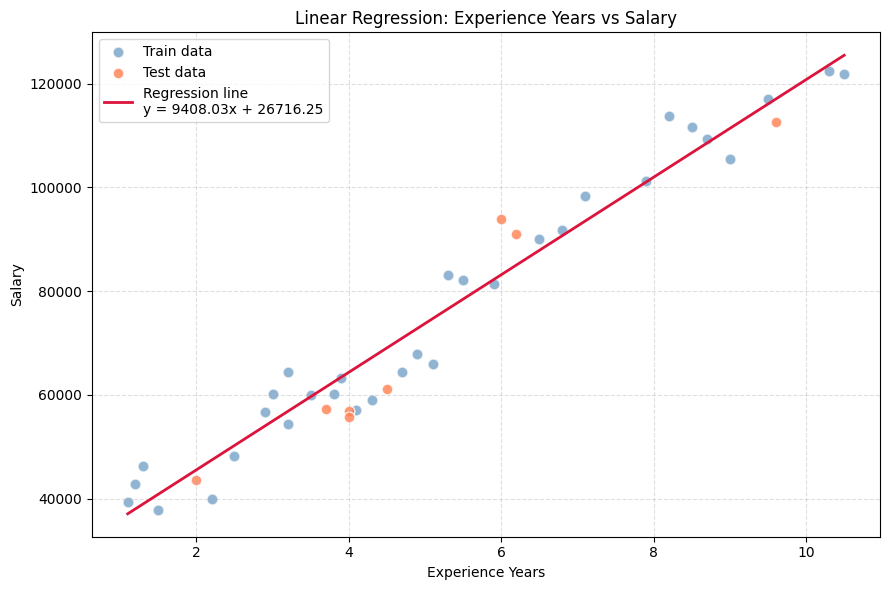

In [19]:
# Generate x values for a smooth regression line
x_line = np.linspace(X['Experience Years'].min(), X['Experience Years'].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.figure(figsize=(9, 6))

plt.scatter(X_train, y_train, color='steelblue', alpha=0.6, label='Train data', edgecolors='white', s=60)
plt.scatter(X_test,  y_test,  color='coral',     alpha=0.8, label='Test data',  edgecolors='white', s=60)
plt.plot(x_line, y_line, color='crimson', linewidth=2,
         label=f'Regression line\ny = {slope:.2f}x + {intercept:.2f}')

plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.title('Linear Regression: Experience Years vs Salary')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()